## **computer vision - lab 6 tasks**

### 23K-0074

#### setup
downloads every image/video used below (all from public GitHub repos), so the notebook runs top to bottom with no manual uploads.

In [7]:
%pip install -q PyWavelets scikit-image pandas

import os
import urllib.request

base_cv = "https://raw.githubusercontent.com/opencv/opencv/4.x/samples/data"
base_st = "https://raw.githubusercontent.com/opencv/opencv_extra/4.x/testdata/stitching"
base_ln = "https://raw.githubusercontent.com/udacity/CarND-LaneLines-P1/master/test_images"

files = [f"{base_cv}/{f}" for f in ["box.png", "box_in_scene.png", "home.jpg", "aero1.jpg", "graf1.png", "vtest.avi"]]
files += [f"{base_st}/boat{i}.jpg" for i in range(1, 7)]
files += [f"{base_ln}/{f}.jpg" for f in ["solidWhiteCurve", "solidWhiteRight", "solidYellowCurve",
                                         "solidYellowCurve2", "solidYellowLeft", "whiteCarLaneSwitch"]]

for url in files:
    name = url.split("/")[-1]
    if not os.path.exists(name):
        urllib.request.urlretrieve(url, name)
    print(f"{name:25s} {os.path.getsize(name) / 1024:8.0f} KB")
print("\nall files saved in:", os.getcwd())


[notice] A new release of pip is available: 25.1.1 -> 26.2.1
[notice] To update, run: C:\Users\ibrah\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
box.png                         50 KB
box_in_scene.png               120 KB
home.jpg                        31 KB
aero1.jpg                       59 KB
graf1.png                      929 KB
vtest.avi                     7941 KB
boat1.jpg                      718 KB
boat2.jpg                      649 KB
boat3.jpg                      687 KB
boat4.jpg                      645 KB
boat5.jpg                      713 KB
boat6.jpg                      712 KB
solidWhiteCurve.jpg             49 KB
solidWhiteRight.jpg             69 KB
solidYellowCurve.jpg            57 KB
solidYellowCurve2.jpg           65 KB
solidYellowLeft.jpg             66 KB
whiteCarLaneSwitch.jpg          59 KB

all files saved in: c:\Ibrahim\Personal\University Stuff\Computer Vision\Labs\06


In [8]:
import cv2
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
from skimage import data

def show(img, title="", cmap=None):
    if img.ndim == 3:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.imshow(img, cmap=cmap)
    plt.title(title)
    plt.axis("off")

sift = cv2.SIFT_create()
print("opencv", cv2.__version__, "| pywt", pywt.__version__)

opencv 4.13.0 | pywt 1.8.0


# **lab timing task 1: computer screen detection (hough lines)**
no public photo of a computer lab with a known ground truth was available, so the cell below generates a lab scene: 2 rows of 4 desks, with screens that are on, off, or missing. to use a real photo, set `scene = cv2.imread("your_photo.jpg")` instead.

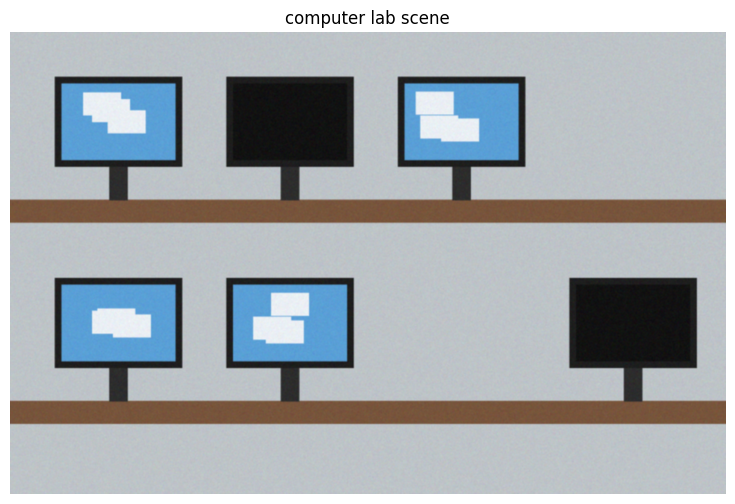

In [9]:
def make_lab_scene(states, seed=0):
    rng = np.random.default_rng(seed)
    h, w = 620, 960
    img = np.full((h, w, 3), (200, 196, 190), np.uint8)
    rows_y, cols_x, mw, mh = [60, 330], [60, 290, 520, 750], 170, 120
    for r, y in enumerate(rows_y):
        cv2.rectangle(img, (0, y + mh + 45), (w, y + mh + 75), (60, 85, 120), -1)
        for c, x in enumerate(cols_x):
            s = states[r][c]
            if s == "missing":
                continue
            cv2.rectangle(img, (x + mw // 2 - 12, y + mh), (x + mw // 2 + 12, y + mh + 45), (45, 45, 45), -1)
            cv2.rectangle(img, (x, y), (x + mw, y + mh), (30, 30, 30), -1)
            if s == "on":
                cv2.rectangle(img, (x + 9, y + 9), (x + mw - 9, y + mh - 9), (215, 160, 90), -1)
                for k in range(3):
                    wx, wy = x + 20 + int(rng.integers(0, 60)), y + 20 + int(rng.integers(0, 40))
                    cv2.rectangle(img, (wx, wy), (wx + 50, wy + 30), (245, 240, 235), -1)
            else:
                cv2.rectangle(img, (x + 9, y + 9), (x + mw - 9, y + mh - 9), (18, 18, 18), -1)
    noise = rng.normal(0, 6, img.shape)
    img = np.clip(img + noise, 0, 255).astype(np.uint8)
    return cv2.GaussianBlur(img, (3, 3), 0)

lab_states = [["on", "off", "on", "missing"],
              ["on", "on", "missing", "off"]]
scene = make_lab_scene(lab_states)

plt.figure(figsize=(10, 6))
show(scene, "computer lab scene")
plt.show()

In [10]:
gray = cv2.cvtColor(scene, cv2.COLOR_BGR2GRAY)
edges = cv2.Canny(cv2.GaussianBlur(gray, (7, 7), 0), 50, 150)
lines = cv2.HoughLinesP(edges, rho=1, theta=np.pi / 180, threshold=50,
                        minLineLength=60, maxLineGap=20)

# split into horizontal / vertical segments, ignore everything else
horizontal, vertical = [], []
for x1, y1, x2, y2 in lines.reshape(-1, 4):
    angle = abs(np.degrees(np.arctan2(y2 - y1, x2 - x1))) % 180
    if angle < 3 or angle > 177:
        horizontal.append((min(x1, x2), max(x1, x2), (y1 + y2) / 2))
    elif 87 < angle < 93:
        vertical.append((min(y1, y2), max(y1, y2), (x1 + x2) / 2))

# fuse broken pieces of the same border (and the bezel's inner/outer edge)
def merge(segs, tol=15):
    merged = []
    for a1, a2, c in sorted(segs, key=lambda s: s[2]):
        for m in merged:
            if abs(m[2] - c) < tol and a1 < m[1] + 30 and a2 > m[0] - 30:
                m[0], m[1], m[2] = min(m[0], a1), max(m[1], a2), (m[2] + c) / 2
                break
        else:
            merged.append([a1, a2, c])
    return merged

vertical, horizontal = merge(vertical), merge(horizontal)
print(f"hough segments: {len(lines)} -> {len(horizontal)} horizontal + {len(vertical)} vertical borders after merging")

# a screen = two vertical borders at a plausible width apart, joined by a horizontal top border
screens, used = [], set()
vertical.sort(key=lambda v: v[2])
for i, L in enumerate(vertical):
    if i in used:
        continue
    for j in range(i + 1, len(vertical)):
        R = vertical[j]
        gap = R[2] - L[2]
        overlap = min(L[1], R[1]) - max(L[0], R[0])
        if j in used or not (120 < gap < 260) or overlap < 0.7 * max(L[1] - L[0], R[1] - R[0]):
            continue
        top, bottom = max(L[0], R[0]), min(L[1], R[1])
        if any(abs(hy - top) < 12 and min(hx2, R[2]) - max(hx1, L[2]) > 0.4 * gap for hx1, hx2, hy in horizontal):
            screens.append((int(L[2]), int(top), int(gap), int(bottom - top)))
            used.update([i, j])
            break

line_vis = np.zeros_like(gray)
for x1, y1, x2, y2 in lines.reshape(-1, 4):
    cv2.line(line_vis, (int(x1), int(y1)), (int(x2), int(y2)), 255, 2)
print("screens detected:", len(screens))

hough segments: 74 -> 20 horizontal + 12 vertical borders after merging
screens detected: 6


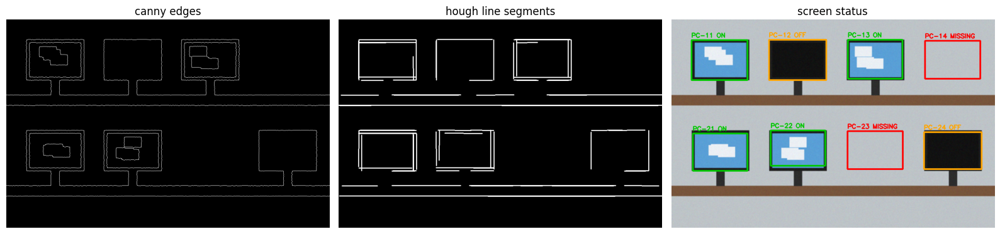

 desk  row  col  status
PC-11    1    1      ON
PC-12    1    2     OFF
PC-13    1    3      ON
PC-14    1    4 MISSING
PC-21    2    1      ON
PC-22    2    2      ON
PC-23    2    3 MISSING
PC-24    2    4     OFF

anomalies: PC-14, PC-23


In [11]:
def cluster(values, tol):
    groups = []
    for v in sorted(values):
        if groups and v - groups[-1][-1] < tol:
            groups[-1].append(v)
        else:
            groups.append([v])
    return [np.mean(g) for g in groups]

# expected grid of desks from the detected screens
row_centers = cluster([y + h / 2 for x, y, w, h in screens], 60)
col_centers = cluster([x + w / 2 for x, y, w, h in screens], 60)
med_w = int(np.median([s[2] for s in screens]))
med_h = int(np.median([s[3] for s in screens]))

hsv = cv2.cvtColor(scene, cv2.COLOR_BGR2HSV)
result = scene.copy()
report = []

for r, ry in enumerate(row_centers):
    for c, cx in enumerate(col_centers):
        match = [s for s in screens if abs(s[0] + s[2] / 2 - cx) < 40 and abs(s[1] + s[3] / 2 - ry) < 40]
        if match:
            x, y, w, h = match[0]
            inner = hsv[y + h // 5: y + 4 * h // 5, x + w // 5: x + 4 * w // 5, 2]
            status = "ON" if inner.mean() > 80 else "OFF"
            color = (0, 200, 0) if status == "ON" else (0, 165, 255)
        else:
            x, y, w, h = int(cx - med_w / 2), int(ry - med_h / 2), med_w, med_h
            status, color = "MISSING", (0, 0, 255)
        cv2.rectangle(result, (x, y), (x + w, y + h), color, 3)
        cv2.putText(result, f"PC-{r + 1}{c + 1} {status}", (x, y - 8),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, color, 2)
        report.append({"desk": f"PC-{r + 1}{c + 1}", "row": r + 1, "col": c + 1, "status": status})

plt.figure(figsize=(16, 5))
plt.subplot(1, 3, 1); show(edges, "canny edges", cmap="gray")
plt.subplot(1, 3, 2); show(line_vis, "hough line segments", cmap="gray")
plt.subplot(1, 3, 3); show(result, "screen status")
plt.tight_layout(); plt.show()

report = pd.DataFrame(report)
print(report.to_string(index=False))
print("\nanomalies:", ", ".join(report[report.status == "MISSING"].desk) or "none")

# **lab timing task 2: asset tracking with sift**
each asset is registered once as a reference image (monitors are identified by what's on screen plus their asset tag, the keyboard by its key layout). the lab photo is then searched for every registered asset. PC-03 is registered but not placed in the scene, so the inventory should flag it as missing.

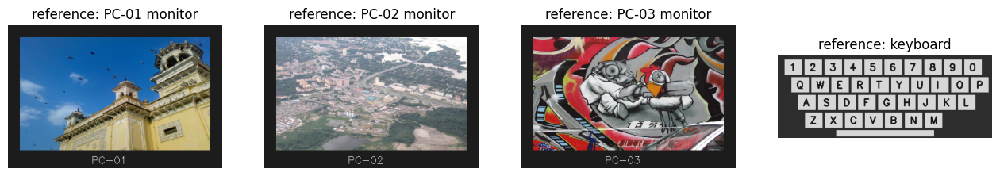

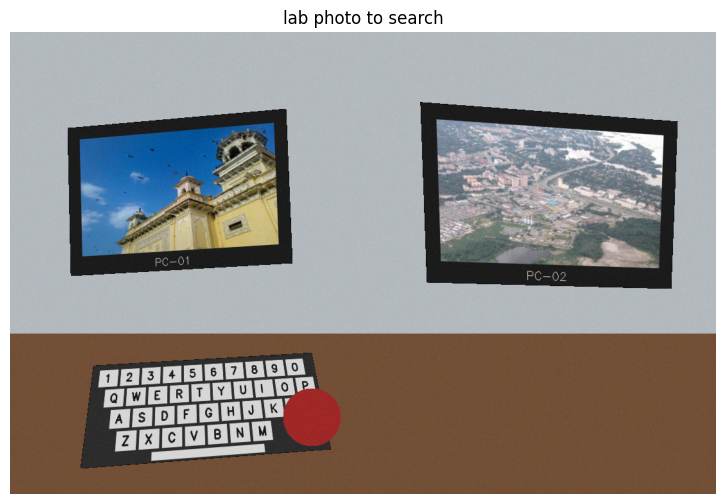

In [12]:
font = cv2.FONT_HERSHEY_SIMPLEX

def make_monitor(content, tag):
    mon = np.full((240, 360, 3), 28, np.uint8)
    mon[20:210, 20:340] = cv2.resize(content, (320, 190))
    cv2.putText(mon, tag, (140, 232), font, 0.55, (210, 210, 210), 1)
    return mon

def make_keyboard():
    kb = np.full((170, 440, 3), 45, np.uint8)
    for r, keys in enumerate(["1234567890", "QWERTYUIOP", "ASDFGHJKL", "ZXCVBNM"]):
        for k, ch in enumerate(keys):
            x, y = 14 + r * 14 + k * 41, 10 + r * 36
            cv2.rectangle(kb, (x, y), (x + 35, y + 30), (215, 215, 215), -1)
            cv2.putText(kb, ch, (x + 10, y + 22), font, 0.65, (25, 25, 25), 2)
    cv2.rectangle(kb, (120, 154), (320, 166), (215, 215, 215), -1)
    return kb

assets = {
    "PC-01 monitor": make_monitor(cv2.imread("home.jpg"), "PC-01"),
    "PC-02 monitor": make_monitor(cv2.imread("aero1.jpg"), "PC-02"),
    "PC-03 monitor": make_monitor(cv2.imread("graf1.png"), "PC-03"),
    "keyboard": make_keyboard(),
}

def place(canvas, obj, quad):
    h, w = obj.shape[:2]
    src = np.float32([[0, 0], [w, 0], [w, h], [0, h]])
    H = cv2.getPerspectiveTransform(src, np.float32(quad))
    warped = cv2.warpPerspective(obj, H, canvas.shape[1::-1])
    mask = cv2.warpPerspective(np.full((h, w), 255, np.uint8), H, canvas.shape[1::-1])
    canvas[mask > 0] = warped[mask > 0]

lab_photo = np.full((720, 1100, 3), (190, 186, 180), np.uint8)
cv2.rectangle(lab_photo, (0, 470), (1100, 720), (55, 80, 115), -1)
place(lab_photo, assets["PC-01 monitor"], [[90, 150], [430, 120], [440, 360], [95, 380]])
place(lab_photo, assets["PC-02 monitor"], [[640, 110], [1040, 140], [1030, 400], [650, 390]])
place(lab_photo, assets["keyboard"], [[130, 520], [470, 500], [500, 650], [110, 680]])
cv2.circle(lab_photo, (470, 600), 45, (40, 40, 160), -1)   # mug partly covering the keyboard
lab_photo = np.clip(lab_photo + np.random.default_rng(1).normal(0, 4, lab_photo.shape), 0, 255).astype(np.uint8)

plt.figure(figsize=(16, 4))
for i, (name, img) in enumerate(assets.items()):
    plt.subplot(1, 4, i + 1); show(img, f"reference: {name}")
plt.show()
plt.figure(figsize=(10, 6)); show(lab_photo, "lab photo to search"); plt.show()

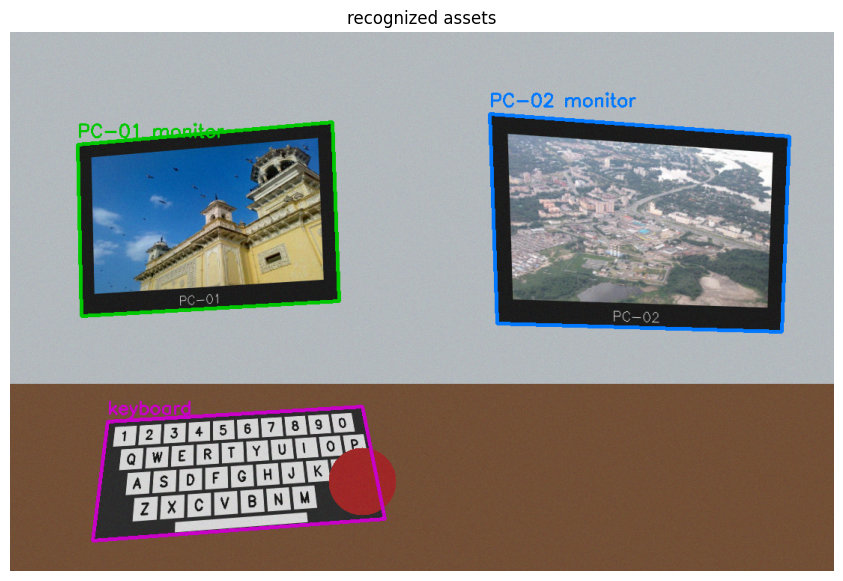

        asset  sift matches  ransac inliers    status
PC-01 monitor           249             242   present
PC-02 monitor           599             594   present
PC-03 monitor             5               0 NOT FOUND
     keyboard           171             145   present


In [13]:
bf = cv2.BFMatcher(cv2.NORM_L2)
scene_gray = cv2.cvtColor(lab_photo, cv2.COLOR_BGR2GRAY)
kp_s, des_s = sift.detectAndCompute(scene_gray, None)

tracked = lab_photo.copy()
inventory = []
colors = [(0, 200, 0), (255, 120, 0), (0, 200, 255), (200, 0, 200)]

for (name, ref), color in zip(assets.items(), colors):
    kp_r, des_r = sift.detectAndCompute(cv2.cvtColor(ref, cv2.COLOR_BGR2GRAY), None)
    good = [m for m, n in bf.knnMatch(des_r, des_s, k=2) if m.distance < 0.75 * n.distance]

    inliers, found = 0, False
    if len(good) >= 10:
        src = np.float32([kp_r[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
        dst = np.float32([kp_s[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
        H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
        inliers = int(mask.sum()) if mask is not None else 0
        if inliers >= 15:
            found = True
            h, w = ref.shape[:2]
            box = cv2.perspectiveTransform(np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2), H)
            cv2.polylines(tracked, [np.int32(box)], True, color, 4)
            x, y = np.int32(box[0, 0])
            cv2.putText(tracked, name, (x, y - 10), font, 0.8, color, 2)

    inventory.append({"asset": name, "sift matches": len(good), "ransac inliers": inliers,
                      "status": "present" if found else "NOT FOUND"})

plt.figure(figsize=(11, 7)); show(tracked, "recognized assets"); plt.show()
print(pd.DataFrame(inventory).to_string(index=False))

# **lab timing task 3: anomaly detection in sensor data (wavelets)**
simulated vibration sensor: a periodic machine signal plus noise, with a few injected faults (spikes and a short burst) so we know where the real anomalies are.

In [14]:
rng = np.random.default_rng(42)
n = 1000
t = np.arange(n)
sensor = 0.8 * np.sin(2 * np.pi * t / 100) + rng.normal(0, 0.3, n)

true_anomalies = np.array([120, 275, 430, 610, 790, 905])
sensor[true_anomalies] += rng.choice([-1, 1], len(true_anomalies)) * rng.uniform(2.0, 3.0, len(true_anomalies))
sensor[680:690] += rng.normal(0, 1.5, 10)   # short fault burst

# wavelet decomposition -> soft threshold detail coefficients -> reconstruct
coeffs = pywt.wavedec(sensor, "db4", level=4)
sigma = np.median(np.abs(coeffs[-1])) / 0.6745
threshold = sigma * np.sqrt(2 * np.log(n))
coeffs_d = [coeffs[0]] + [pywt.threshold(c, threshold, mode="soft") for c in coeffs[1:]]
denoised = pywt.waverec(coeffs_d, "db4")[:n]

residuals = sensor - denoised
limit = 3.5 * np.std(residuals)
anomalies = np.where(np.abs(residuals) > limit)[0]

print(f"noise sigma: {sigma:.3f} | threshold: {threshold:.3f} | anomaly limit: +/-{limit:.3f}")
print("detected anomaly indices:", anomalies.tolist())
hits = [a for a in true_anomalies if np.any(np.abs(anomalies - a) <= 2)]
burst = (anomalies >= 678) & (anomalies <= 692)
false_alarms = [a for a in anomalies[~burst] if np.all(np.abs(true_anomalies - a) > 2)]
print(f"injected spikes caught: {len(hits)}/{len(true_anomalies)} | burst caught: {burst.any()} | false alarms: {len(false_alarms)}")

noise sigma: 0.296 | threshold: 1.101 | anomaly limit: +/-1.167
detected anomaly indices: [120, 275, 430, 610, 682, 684, 790, 905]
injected spikes caught: 6/6 | burst caught: True | false alarms: 0


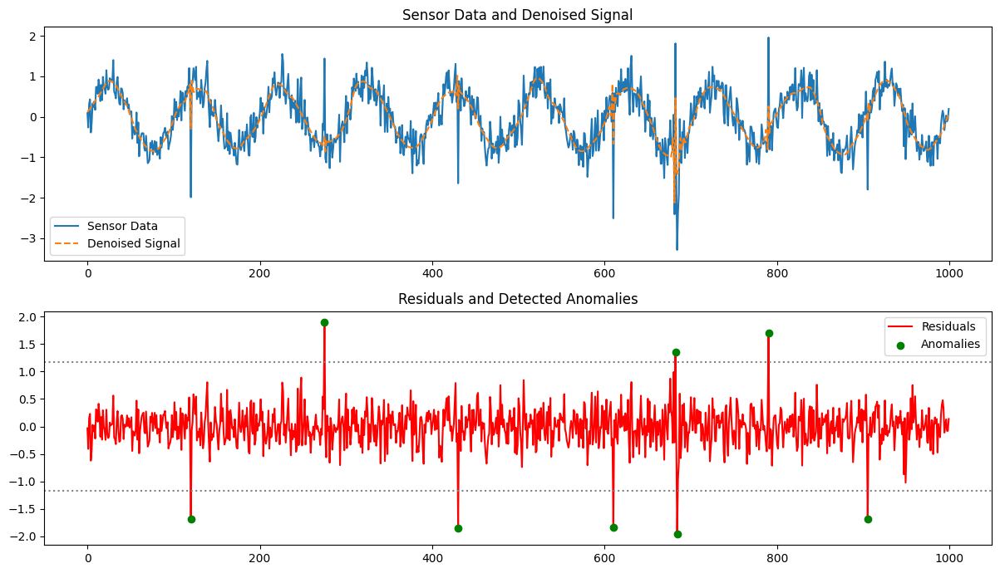

In [15]:
plt.figure(figsize=(12, 7))

plt.subplot(2, 1, 1)
plt.plot(t, sensor, label="Sensor Data")
plt.plot(t, denoised, "--", label="Denoised Signal")
plt.title("Sensor Data and Denoised Signal")
plt.legend()

plt.subplot(2, 1, 2)
plt.plot(t, residuals, "r", label="Residuals")
plt.scatter(anomalies, residuals[anomalies], c="green", zorder=3, label="Anomalies")
plt.axhline(limit, color="gray", ls=":"); plt.axhline(-limit, color="gray", ls=":")
plt.title("Residuals and Detected Anomalies")
plt.legend()

plt.tight_layout(); plt.show()

# **task 1: object recognition (using video)**
reference object: `box.png`. the test video is generated from it: the box moves across a background while changing scale and rotating through 360°, and a block covers part of it for a third of the frames (partial occlusion). `box_in_scene.png` is used as an extra real test image.

In [16]:
obj = cv2.imread("box.png")
bg = cv2.resize(cv2.imread("home.jpg"), (640, 480))
oh, ow = obj.shape[:2]

writer = cv2.VideoWriter("test_video.mp4", cv2.VideoWriter_fourcc(*"mp4v"), 15, (640, 480))
n_frames = 90
for i in range(n_frames):
    p = i / (n_frames - 1)
    scale = 0.75 + 0.35 * np.sin(2 * np.pi * p)
    angle = 360 * p
    cx, cy = 180 + 280 * p, 240 + 50 * np.sin(4 * np.pi * p)
    M = cv2.getRotationMatrix2D((ow / 2, oh / 2), angle, scale)
    M[:, 2] += (cx - ow / 2, cy - oh / 2)
    warped = cv2.warpAffine(obj, M, (640, 480))
    mask = cv2.warpAffine(np.full((oh, ow), 255, np.uint8), M, (640, 480))
    frame = bg.copy()
    frame[mask > 0] = warped[mask > 0]
    if 30 <= i < 60:
        cv2.rectangle(frame, (int(cx - 90), int(cy - 110)), (int(cx - 10), int(cy + 110)), (60, 120, 60), -1)
    writer.write(frame)
writer.release()
print("test video written: test_video.mp4,", n_frames, "frames")

test video written: test_video.mp4, 90 frames


reference keypoints: 604
object recognized in 90/90 frames (saved recognized_video.mp4)


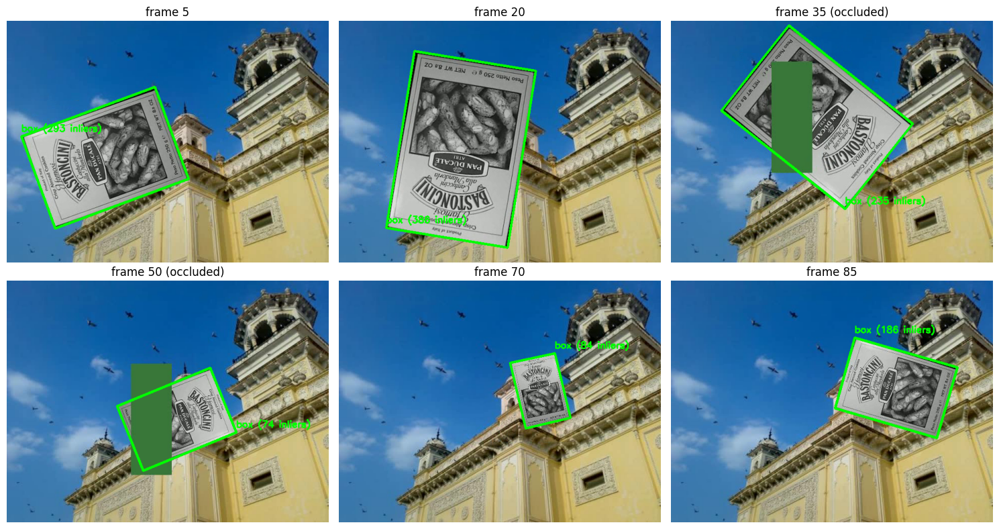

In [17]:
def recognize(frame, kp_ref, des_ref, ref_shape, min_inliers=12):
    kp, des = sift.detectAndCompute(cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY), None)
    out = frame.copy()
    if des is None or len(kp) < 2:
        return out, 0
    good = [m for m, n in bf.knnMatch(des_ref, des, k=2) if m.distance < 0.75 * n.distance]
    if len(good) < 8:
        return out, 0
    src = np.float32([kp_ref[m.queryIdx].pt for m in good]).reshape(-1, 1, 2)
    dst = np.float32([kp[m.trainIdx].pt for m in good]).reshape(-1, 1, 2)
    H, mask = cv2.findHomography(src, dst, cv2.RANSAC, 5.0)
    inliers = int(mask.sum()) if mask is not None else 0
    if inliers >= min_inliers:
        h, w = ref_shape
        box = cv2.perspectiveTransform(np.float32([[0, 0], [w, 0], [w, h], [0, h]]).reshape(-1, 1, 2), H)
        cv2.polylines(out, [np.int32(box)], True, (0, 255, 0), 3)
        cv2.putText(out, f"box ({inliers} inliers)", tuple(np.int32(box[0, 0]) - [0, 10]), font, 0.6, (0, 255, 0), 2)
    return out, inliers

kp_ref, des_ref = sift.detectAndCompute(cv2.cvtColor(obj, cv2.COLOR_BGR2GRAY), None)
print("reference keypoints:", len(kp_ref))

cap = cv2.VideoCapture("test_video.mp4")
out_writer = cv2.VideoWriter("recognized_video.mp4", cv2.VideoWriter_fourcc(*"mp4v"), 15, (640, 480))
samples, detected, idx = [], 0, 0
while True:
    ok, frame = cap.read()
    if not ok:
        break
    out, inl = recognize(frame, kp_ref, des_ref, obj.shape[:2])
    detected += inl >= 12
    out_writer.write(out)
    if idx in (5, 20, 35, 50, 70, 85):
        samples.append((idx, out))
    idx += 1
cap.release(); out_writer.release()
print(f"object recognized in {detected}/{idx} frames (saved recognized_video.mp4)")

plt.figure(figsize=(15, 8))
for k, (i, f) in enumerate(samples):
    plt.subplot(2, 3, k + 1)
    show(f, f"frame {i}" + (" (occluded)" if 30 <= i < 60 else ""))
plt.tight_layout(); plt.show()

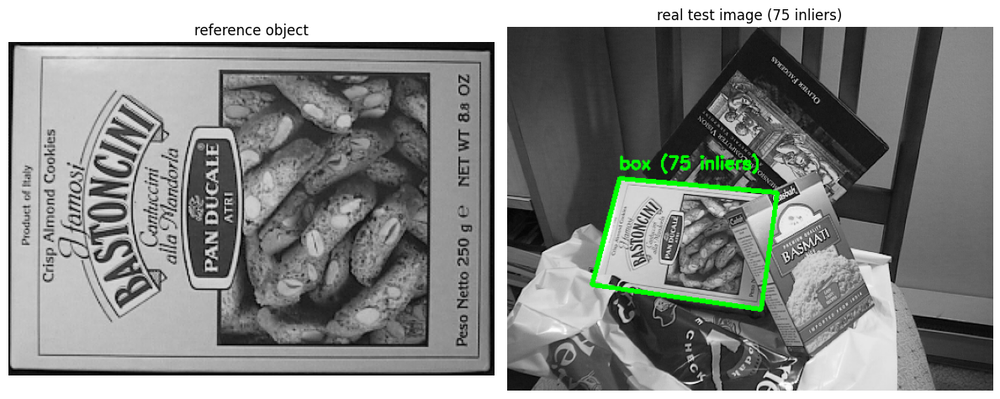

In [18]:
test_img = cv2.imread("box_in_scene.png")
out, inl = recognize(test_img, kp_ref, des_ref, obj.shape[:2])
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1); show(obj, "reference object")
plt.subplot(1, 2, 2); show(out, f"real test image ({inl} inliers)")
plt.tight_layout(); plt.show()

# **task 2: your panoramic image**
six overlapping shots of a river skyline taken while panning the camera left to right (`boat1-6.jpg`, from OpenCV's stitching test data, downscaled to 20%). SIFT matches adjacent pairs, each image is first projected onto a cylinder (so turning the camera becomes a sideways shift), then RANSAC finds the transform between neighbours and every image is chained into image 1's frame. a plain homography chain over 6 images bends into a bow-tie shape, which the cylinder projection avoids.

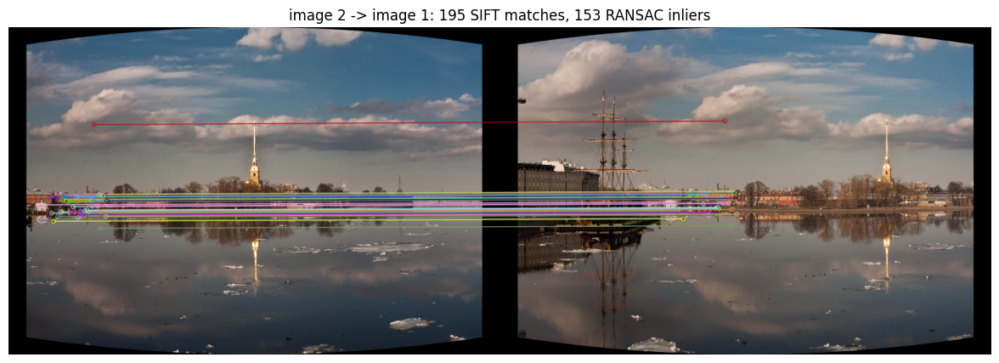

image 2 -> image 1: 195 matches, 153 inliers, shift x=221.4px y=-4.8px
image 3 -> image 2: 192 matches, 143 inliers, shift x=267.6px y=12.2px
image 4 -> image 3: 96 matches, 71 inliers, shift x=364.9px y=13.4px
image 5 -> image 4: 142 matches, 82 inliers, shift x=318.9px y=-4.0px
image 6 -> image 5: 167 matches, 101 inliers, shift x=236.6px y=2.3px


In [19]:
pano_imgs = [cv2.resize(cv2.imread(f"boat{i}.jpg"), None, fx=0.2, fy=0.2) for i in range(1, 7)]

def cylindrical(img, f):
    # project onto a cylinder so a camera pan becomes a sideways shift
    h, w = img.shape[:2]
    ys, xs = np.indices((h, w)).astype(np.float32)
    theta, height = (xs - w / 2) / f, (ys - h / 2) / f
    map_x = (f * np.tan(theta) + w / 2).astype(np.float32)
    map_y = (height * f / np.cos(theta) + h / 2).astype(np.float32)
    return cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR, borderMode=cv2.BORDER_CONSTANT)

focal = pano_imgs[0].shape[1]
cyl_imgs = [cylindrical(img, focal) for img in pano_imgs]

def match_pair(dst_img, src_img):
    k1, d1 = sift.detectAndCompute(cv2.cvtColor(dst_img, cv2.COLOR_BGR2GRAY), None)
    k2, d2 = sift.detectAndCompute(cv2.cvtColor(src_img, cv2.COLOR_BGR2GRAY), None)
    good = [m for m, n in bf.knnMatch(d2, d1, k=2) if m.distance < 0.7 * n.distance]
    src = np.float32([k2[m.queryIdx].pt for m in good])
    dst = np.float32([k1[m.trainIdx].pt for m in good])
    M, inliers = cv2.estimateAffinePartial2D(src, dst, method=cv2.RANSAC, ransacReprojThreshold=3.0)
    return np.vstack([M, [0, 0, 1]]), good, inliers, k1, k2

M01, good, inliers, k1, k2 = match_pair(cyl_imgs[0], cyl_imgs[1])
inl = [g for g, keep in zip(good, inliers.ravel()) if keep][:40]
vis = cv2.drawMatches(cyl_imgs[1], k2, cyl_imgs[0], k1, inl, None, flags=2)
plt.figure(figsize=(15, 5)); show(vis, f"image 2 -> image 1: {len(good)} SIFT matches, {int(inliers.sum())} RANSAC inliers"); plt.show()

# chain the pairwise transforms so every image lands in image 1's frame
Ts = [np.eye(3)]
for i in range(1, len(cyl_imgs)):
    M, good, inliers, _, _ = match_pair(cyl_imgs[i - 1], cyl_imgs[i])
    Ts.append(Ts[-1] @ M)
    print(f"image {i + 1} -> image {i}: {len(good)} matches, {int(inliers.sum())} inliers, shift x={M[0, 2]:.1f}px y={M[1, 2]:.1f}px")

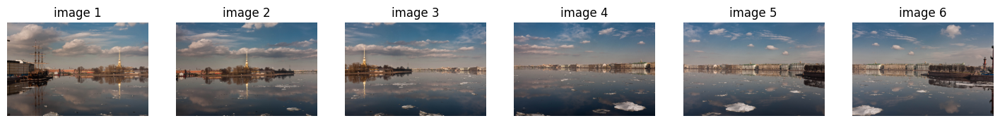

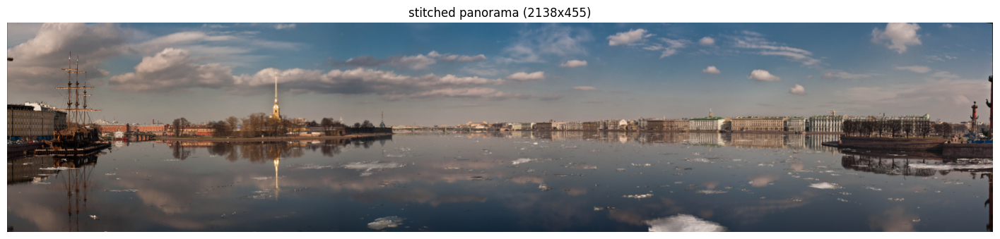

In [20]:
h0, w0 = cyl_imgs[0].shape[:2]
box = np.float32([[0, 0], [w0, 0], [w0, h0], [0, h0]]).reshape(-1, 1, 2)
corners = np.concatenate([cv2.perspectiveTransform(box, T) for T in Ts])
xmin, ymin = np.floor(corners.min(axis=(0, 1))).astype(int)
xmax, ymax = np.ceil(corners.max(axis=(0, 1))).astype(int)
offset = np.array([[1, 0, -xmin], [0, 1, -ymin], [0, 0, 1]], dtype=np.float64)
size = (xmax - xmin, ymax - ymin)

# feather blending: weight each pixel by its distance to the image border
acc = np.zeros((size[1], size[0], 3), np.float64)
wsum = np.zeros((size[1], size[0]), np.float64)
for img, T in zip(cyl_imgs, Ts):
    warped = cv2.warpPerspective(img, offset @ T, size)
    m = cv2.warpPerspective((img.max(axis=2) > 0).astype(np.uint8) * 255, offset @ T, size)
    wgt = cv2.distanceTransform(m, cv2.DIST_L2, 5)
    acc += warped * wgt[..., None]
    wsum += wgt
panorama = (acc / np.maximum(wsum, 1e-6)[..., None]).astype(np.uint8)

# crop away the black border
valid = wsum > 0
rows = np.where(valid.mean(axis=1) > 0.97)[0]
cols = np.where(valid[rows].mean(axis=0) > 0.99)[0]
panorama = panorama[rows.min():rows.max() + 1, cols.min():cols.max() + 1]
cv2.imwrite("panorama.jpg", panorama)

plt.figure(figsize=(18, 3))
for i, img in enumerate(pano_imgs):
    plt.subplot(1, len(pano_imgs), i + 1); show(img, f"image {i + 1}")
plt.show()
plt.figure(figsize=(18, 5)); show(panorama, f"stitched panorama ({panorama.shape[1]}x{panorama.shape[0]})"); plt.show()

# **task 3: lane detection (hough lines)**
dashcam frames from Udacity's self-driving car lane-lines project, with white and yellow lanes, straight and curved road.

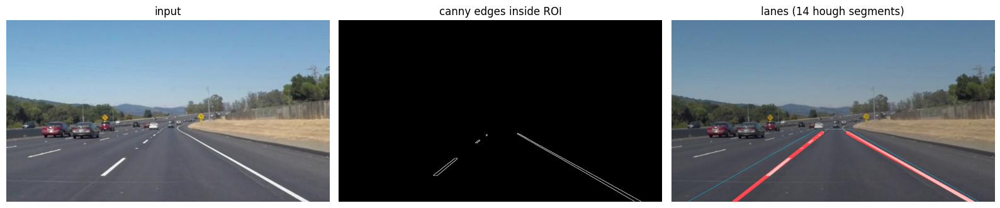

In [21]:
lane_files = ["solidWhiteCurve", "solidWhiteRight", "solidYellowCurve",
              "solidYellowCurve2", "solidYellowLeft", "whiteCarLaneSwitch"]

def lane_mask(img):
    hls = cv2.cvtColor(img, cv2.COLOR_BGR2HLS)
    white = cv2.inRange(hls, (0, 200, 0), (180, 255, 255))
    yellow = cv2.inRange(hls, (15, 30, 100), (35, 204, 255))
    return cv2.bitwise_and(img, img, mask=cv2.bitwise_or(white, yellow))

def region_of_interest(edges):
    h, w = edges.shape
    roi = np.array([[(int(0.05 * w), h), (int(0.45 * w), int(0.6 * h)),
                     (int(0.55 * w), int(0.6 * h)), (int(0.95 * w), h)]], np.int32)
    mask = np.zeros_like(edges)
    cv2.fillPoly(mask, roi, 255)
    return cv2.bitwise_and(edges, mask), roi

def average_lane(lines, h):
    left, right = [], []
    for x1, y1, x2, y2 in lines.reshape(-1, 4):
        if x1 == x2:
            continue
        slope = (y2 - y1) / (x2 - x1)
        length = np.hypot(x2 - x1, y2 - y1)
        if slope < -0.4:
            left.append((slope, y1 - slope * x1, length))
        elif slope > 0.4:
            right.append((slope, y1 - slope * x1, length))
    lanes = []
    for side in (left, right):
        if side:
            s = np.array(side)
            slope, intercept = np.average(s[:, :2], axis=0, weights=s[:, 2])
            y_bottom, y_top = h, int(0.62 * h)
            lanes.append(((int((y_bottom - intercept) / slope), y_bottom),
                          (int((y_top - intercept) / slope), y_top)))
    return lanes

def detect_lanes(img):
    gray = cv2.cvtColor(lane_mask(img), cv2.COLOR_BGR2GRAY)
    edges = cv2.Canny(cv2.GaussianBlur(gray, (5, 5), 0), 50, 150)
    roi_edges, roi = region_of_interest(edges)
    lines = cv2.HoughLinesP(roi_edges, rho=2, theta=np.pi / 180, threshold=20,
                            minLineLength=20, maxLineGap=150)
    overlay = np.zeros_like(img)
    if lines is not None:
        for p1, p2 in average_lane(lines, img.shape[0]):
            cv2.line(overlay, p1, p2, (0, 0, 255), 10)
    out = cv2.addWeighted(img, 0.8, overlay, 1.0, 0)
    cv2.polylines(out, roi, True, (255, 200, 0), 1)
    return out, roi_edges, 0 if lines is None else len(lines)

# intermediate steps for the first image
img = cv2.imread(f"{lane_files[0]}.jpg")
out, roi_edges, nl = detect_lanes(img)
plt.figure(figsize=(16, 4))
plt.subplot(1, 3, 1); show(img, "input")
plt.subplot(1, 3, 2); show(roi_edges, "canny edges inside ROI", cmap="gray")
plt.subplot(1, 3, 3); show(out, f"lanes ({nl} hough segments)")
plt.tight_layout(); plt.show()

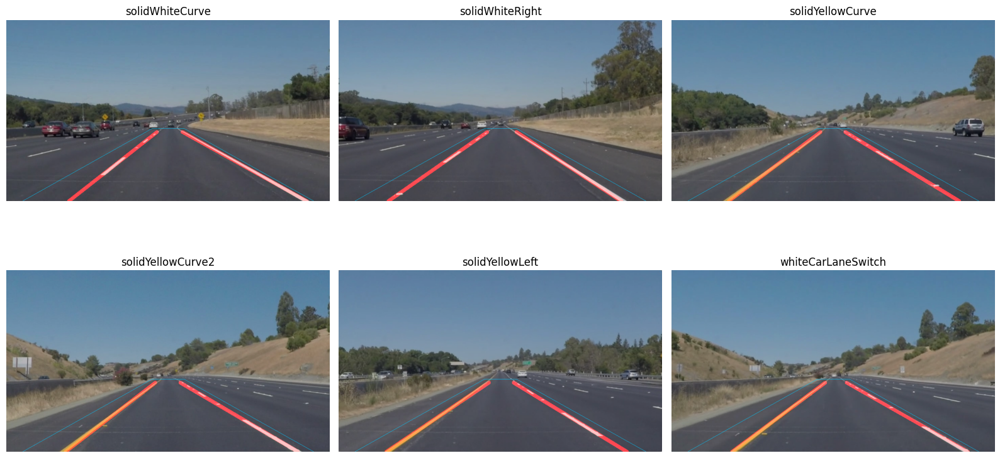

In [22]:
plt.figure(figsize=(16, 9))
for i, f in enumerate(lane_files):
    out, _, nl = detect_lanes(cv2.imread(f"{f}.jpg"))
    plt.subplot(2, 3, i + 1); show(out, f)
plt.tight_layout(); plt.show()

# **task 4: coins detection and counting (hough circles)**
`coins` from scikit-image's sample data (24 coins, different sizes). the second test image is the same photo rotated, rescaled and with lower brightness, to check the detector isn't tuned to one exact layout.

coins.png: 24 coins | radius range 17-32 px
coins rotated + scaled 1.3x + darker: 24 coins | radius range 24-41 px


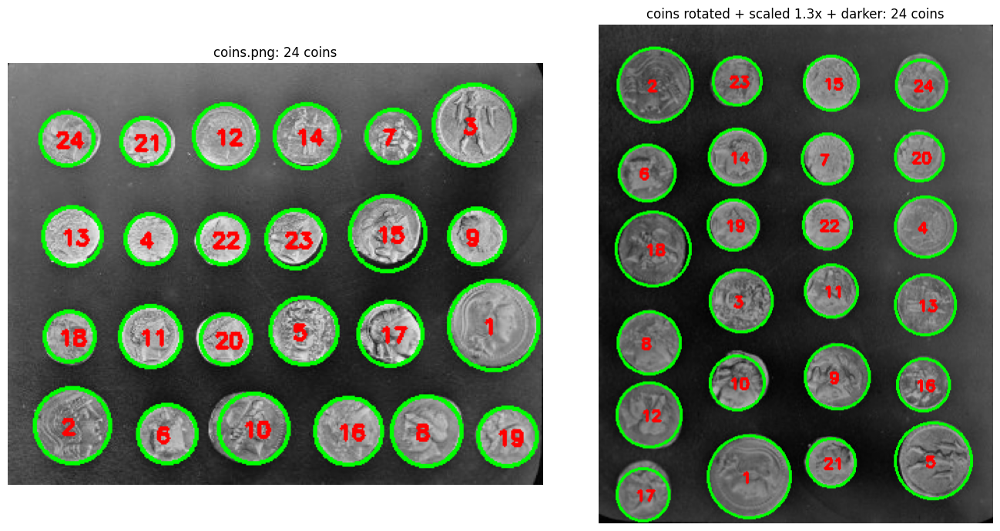

In [23]:
coins1 = cv2.cvtColor(data.coins(), cv2.COLOR_GRAY2BGR)
coins2 = cv2.resize(cv2.rotate(coins1, cv2.ROTATE_90_CLOCKWISE), None, fx=1.3, fy=1.3)
coins2 = cv2.convertScaleAbs(coins2, alpha=0.8, beta=-10)

def count_coins(img, min_r, max_r):
    gray = cv2.medianBlur(cv2.cvtColor(img, cv2.COLOR_BGR2GRAY), 5)
    circles = cv2.HoughCircles(gray, cv2.HOUGH_GRADIENT, dp=1, minDist=int(1.6 * min_r),
                               param1=100, param2=20, minRadius=min_r, maxRadius=max_r)
    out = img.copy()
    circles = [] if circles is None else np.round(circles[0]).astype(int)
    for k, (x, y, r) in enumerate(circles, 1):
        cv2.circle(out, (x, y), r, (0, 255, 0), 2)
        cv2.putText(out, str(k), (x - 8, y + 6), font, 0.5, (0, 0, 255), 2)
    return out, circles

tests = [("coins.png", coins1, 13, 35), ("coins rotated + scaled 1.3x + darker", coins2, 17, 45)]
plt.figure(figsize=(14, 7))
for i, (name, img, rmin, rmax) in enumerate(tests):
    out, circles = count_coins(img, rmin, rmax)
    radii = [c[2] for c in circles]
    print(f"{name}: {len(circles)} coins | radius range {min(radii)}-{max(radii)} px")
    plt.subplot(1, 2, i + 1); show(out, f"{name}: {len(circles)} coins")
plt.tight_layout(); plt.show()

# **task 5: smart security system**
`vtest.avi` (pedestrian CCTV footage from OpenCV) is read frame by frame like a live stream. moving objects are found with background subtraction, their boundaries come from contours, and the alarm fires whenever an object's boundary overlaps the restricted zone. for a live webcam, replace the file name with `cv2.VideoCapture(0)`.

In [24]:
cap = cv2.VideoCapture("vtest.avi")
fw, fh = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH)), int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps = cap.get(cv2.CAP_PROP_FPS)

zone = np.array([[300, 330], [520, 330], [560, 576], [260, 576]], np.int32)
zone_mask = np.zeros((fh, fw), np.uint8)
cv2.fillPoly(zone_mask, [zone], 255)

backsub = cv2.createBackgroundSubtractorMOG2(history=300, varThreshold=40, detectShadows=True)
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
writer = cv2.VideoWriter("security_output.mp4", cv2.VideoWriter_fourcc(*"mp4v"), fps, (fw, fh))

warmup, idx = 30, 0
in_zone_counts, alarm_frames, snapshots = [], [], []
while True:
    ok, frame = cap.read()
    if not ok:
        break
    fg = backsub.apply(frame)
    fg = cv2.threshold(fg, 200, 255, cv2.THRESH_BINARY)[1]          # drop shadows (127)
    fg = cv2.morphologyEx(fg, cv2.MORPH_OPEN, kernel)
    fg = cv2.dilate(cv2.morphologyEx(fg, cv2.MORPH_CLOSE, kernel, iterations=2), kernel, iterations=2)
    contours, _ = cv2.findContours(fg, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

    out = frame.copy()
    overlay = out.copy()
    cv2.fillPoly(overlay, [zone], (0, 0, 255))
    out = cv2.addWeighted(overlay, 0.15, out, 0.85, 0)
    cv2.polylines(out, [zone], True, (0, 0, 255), 2)

    intruders = 0
    for cnt in contours:
        if cv2.contourArea(cnt) < 800 or idx < warmup:
            continue
        obj_mask = np.zeros_like(zone_mask)
        cv2.drawContours(obj_mask, [cnt], -1, 255, -1)
        inside = cv2.countNonZero(cv2.bitwise_and(obj_mask, zone_mask)) > 300
        color = (0, 0, 255) if inside else (0, 220, 0)
        intruders += inside
        cv2.drawContours(out, [cnt], -1, color, 2)
        x, y, w, h = cv2.boundingRect(cnt)
        cv2.rectangle(out, (x, y), (x + w, y + h), color, 1)

    if intruders:
        alarm_frames.append(idx)
        cv2.rectangle(out, (0, 0), (fw, 45), (0, 0, 255), -1)
        cv2.putText(out, f"ALARM: {intruders} object(s) in restricted zone", (10, 32), font, 0.9, (255, 255, 255), 2)
    in_zone_counts.append(intruders)
    writer.write(out)
    if idx in (150, 235, 365, 530, 620, 785):
        snapshots.append((idx, out))
    idx += 1
cap.release(); writer.release()

# group consecutive alarm frames into events
events = []
for f in alarm_frames:
    if events and f - events[-1][1] <= 5:
        events[-1][1] = f
    else:
        events.append([f, f])
print(f"processed {idx} frames, alarm active in {len(alarm_frames)} frames, {len(events)} alarm events")
for s, e in events[:10]:
    print(f"  ALARM  frame {s}-{e}  ({s / fps:.1f}s - {e / fps:.1f}s)")

processed 795 frames, alarm active in 174 frames, 6 alarm events
  ALARM  frame 229-242  (22.9s - 24.2s)
  ALARM  frame 361-370  (36.1s - 37.0s)
  ALARM  frame 516-551  (51.6s - 55.1s)
  ALARM  frame 582-669  (58.2s - 66.9s)
  ALARM  frame 675-680  (67.5s - 68.0s)
  ALARM  frame 771-794  (77.1s - 79.4s)


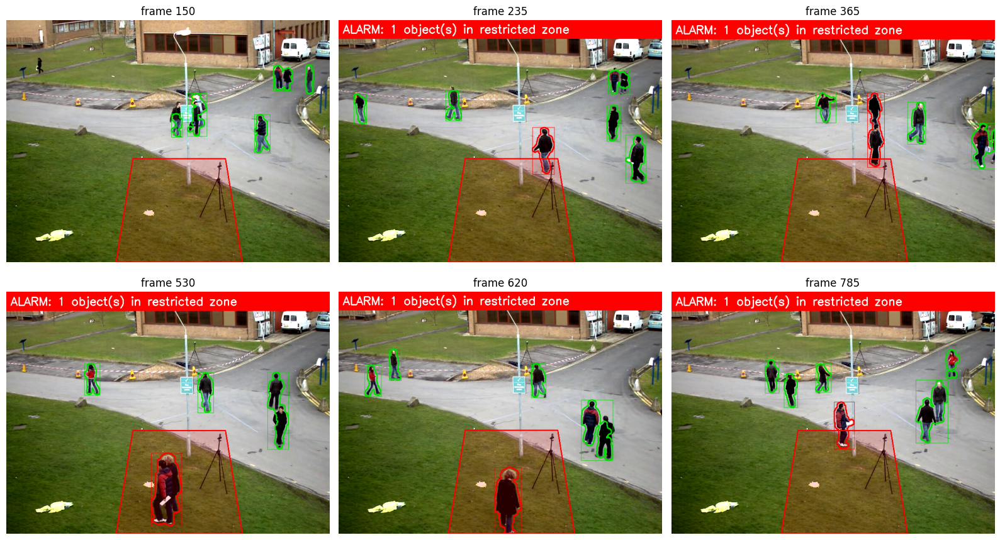

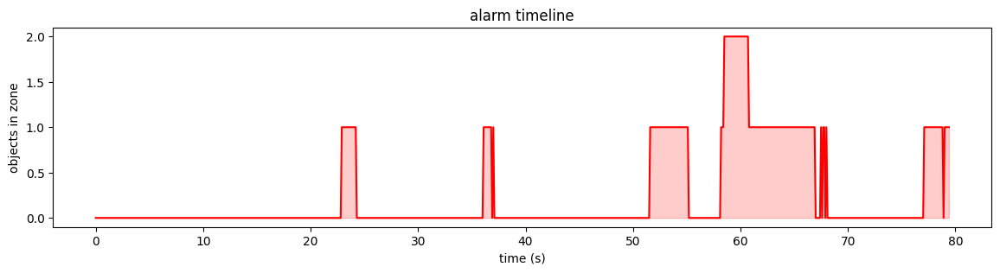

In [25]:
plt.figure(figsize=(16, 9))
for k, (i, f) in enumerate(snapshots):
    plt.subplot(2, 3, k + 1); show(f, f"frame {i}")
plt.tight_layout(); plt.show()

plt.figure(figsize=(14, 3))
plt.plot(np.arange(len(in_zone_counts)) / fps, in_zone_counts, color="red")
plt.fill_between(np.arange(len(in_zone_counts)) / fps, in_zone_counts, color="red", alpha=0.2)
plt.xlabel("time (s)"); plt.ylabel("objects in zone"); plt.title("alarm timeline")
plt.show()